# DeepBranchAI: Destripe Preprocessing Demo

Demonstrates how to remove streak artifacts from light-sheet microscopy images using wavelet-based log-space FFT filtering.

**Destripe method from:**

> Allen Institute for Neural Dynamics - [aind-smartspim-destripe](https://github.com/AllenNeuralDynamics/aind-smartspim-destripe)  
> Licensed under MIT. Implements log-space FFT filtering for removing horizontal/vertical
> streak noise from SmartSPIM light-sheet microscopy datasets.

This notebook generates a synthetic striped image, applies one tuned destripe pass, and visualizes the results.

## Step 1: Install and Import

In [1]:
import subprocess, sys, tempfile
from pathlib import Path

def load_destripe_filter():
    try:
        from aind_smartspim_destripe.filtering import log_space_fft_filtering
        print("aind-smartspim-destripe already available")
        return log_space_fft_filtering
    except ImportError:
        print("Loading aind-smartspim-destripe from GitHub source...")

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "PyWavelets", "scikit-image",
    ])

    repo_dir = Path(tempfile.gettempdir()) / "aind-smartspim-destripe"
    if not repo_dir.exists():
        subprocess.check_call([
            "git", "clone", "--depth", "1", "--quiet",
            "https://github.com/AllenNeuralDynamics/aind-smartspim-destripe.git",
            str(repo_dir),
        ])

    code_dir = repo_dir / "code"
    if str(code_dir) not in sys.path:
        sys.path.insert(0, str(code_dir))

    from aind_smartspim_destripe.filtering import log_space_fft_filtering
    print("aind-smartspim-destripe loaded")
    return log_space_fft_filtering

log_space_fft_filtering = load_destripe_filter()

import numpy as np
import matplotlib.pyplot as plt

Loading aind-smartspim-destripe from GitHub source...


aind-smartspim-destripe loaded


## Step 2: Generate Synthetic Striped Image

In [2]:
np.random.seed(42)

from scipy.ndimage import gaussian_filter

size = 512
yy, xx = np.mgrid[:size, :size]

# Tissue-like background with bright circular structures.
tissue = gaussian_filter(np.random.rand(size, size), sigma=10) * 150 + 45

for _ in range(24):
    cx, cy = np.random.randint(35, size - 35, 2)
    r = np.random.randint(8, 26)
    mask = ((xx - cx) ** 2 + (yy - cy) ** 2) < r ** 2
    tissue[mask] += np.random.uniform(45, 110)

tissue = gaussian_filter(tissue, sigma=0.8)
tissue = np.clip(tissue, 0, 255)

# Add moderate horizontal banding. This keeps the demo readable while still
# showing a clear artifact for the filter to remove.
row = np.linspace(0, 2 * np.pi, size)
stripe_profile = 6 * np.sin(row * 18) + 2 * np.sin(row * 43 + 0.7)
striped_image = np.clip(tissue + stripe_profile[:, None], 0, 255)

print(f"Image shape: {striped_image.shape}")
print(f"Value range: [{striped_image.min():.1f}, {striped_image.max():.1f}]")

Image shape: (512, 512)
Value range: [108.4, 255.0]


## Step 3: Apply Destripe Filtering

In [3]:
sigma = 8
max_threshold = 12

print(f"Applying log-space FFT destriping (sigma={sigma}, threshold={max_threshold})")
filtered_image = log_space_fft_filtering(
    striped_image,
    wavelet='db3',
    level=None,
    sigma=sigma,
    max_threshold=max_threshold,
)

# The filter slightly shifts the global baseline; align medians for comparison.
filtered_image = np.clip(
    filtered_image + (np.median(striped_image) - np.median(filtered_image)),
    0,
    255,
)

def rmse(image, reference):
    return np.sqrt(np.mean((image - reference) ** 2))

def row_bias_std(image, reference):
    return np.std(np.median(image - reference, axis=1))

print("\nBefore/after vs. clean synthetic image")
print(f"RMSE:         {rmse(striped_image, tissue):5.2f} -> {rmse(filtered_image, tissue):5.2f}")
print(f"Row bias std: {row_bias_std(striped_image, tissue):5.2f} -> {row_bias_std(filtered_image, tissue):5.2f}")

print("\nFiltering complete.")

Applying log-space FFT destriping (sigma=8, threshold=12)

Before/after vs. clean synthetic image
RMSE:          4.47 ->  1.91
Row bias std:  4.47 ->  1.41

Filtering complete.


## Step 4: Visualize Results

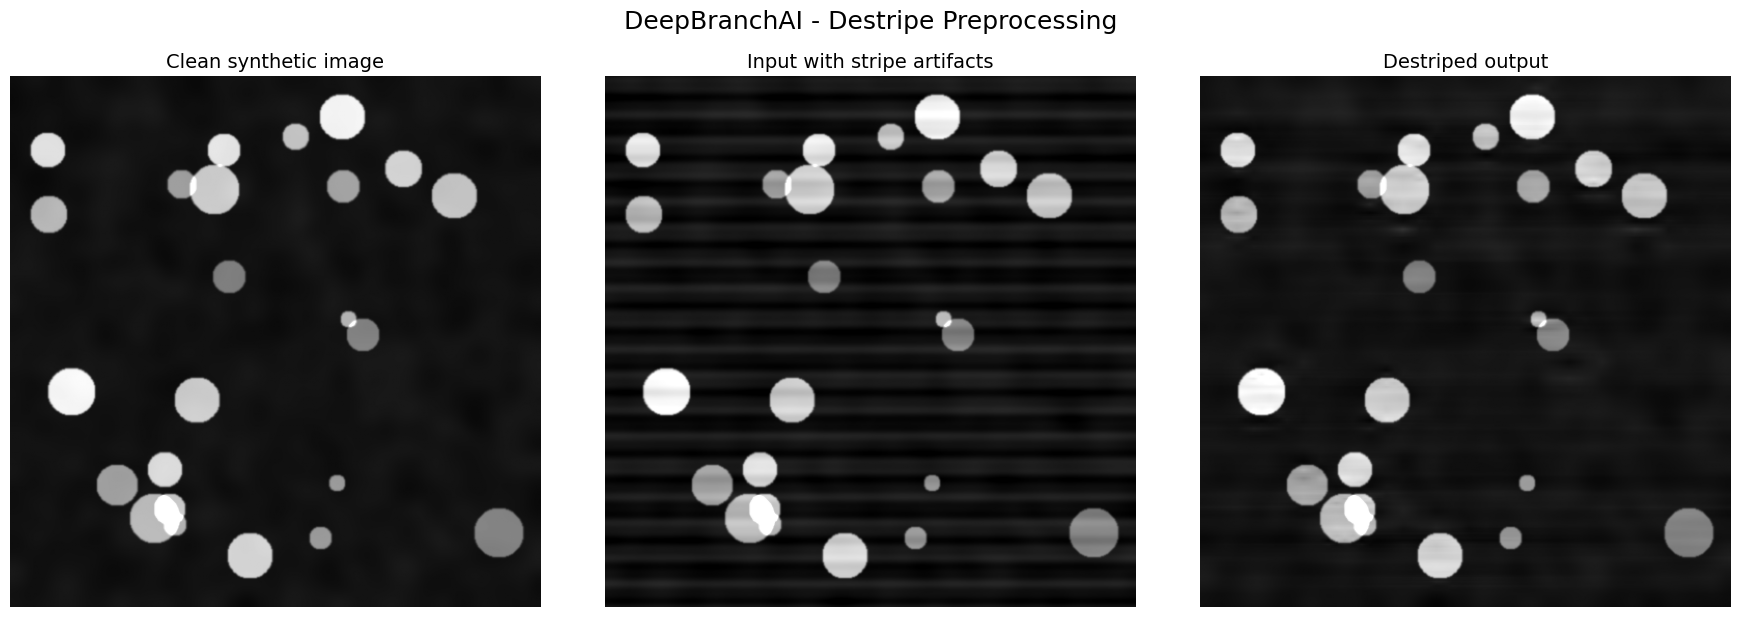

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vmin, vmax = np.percentile(striped_image, [1, 99.5])
panels = [
    ('Clean synthetic image', tissue),
    ('Input with stripe artifacts', striped_image),
    ('Destriped output', filtered_image),
]

for ax, (title, img) in zip(axes, panels):
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.suptitle('DeepBranchAI - Destripe Preprocessing', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

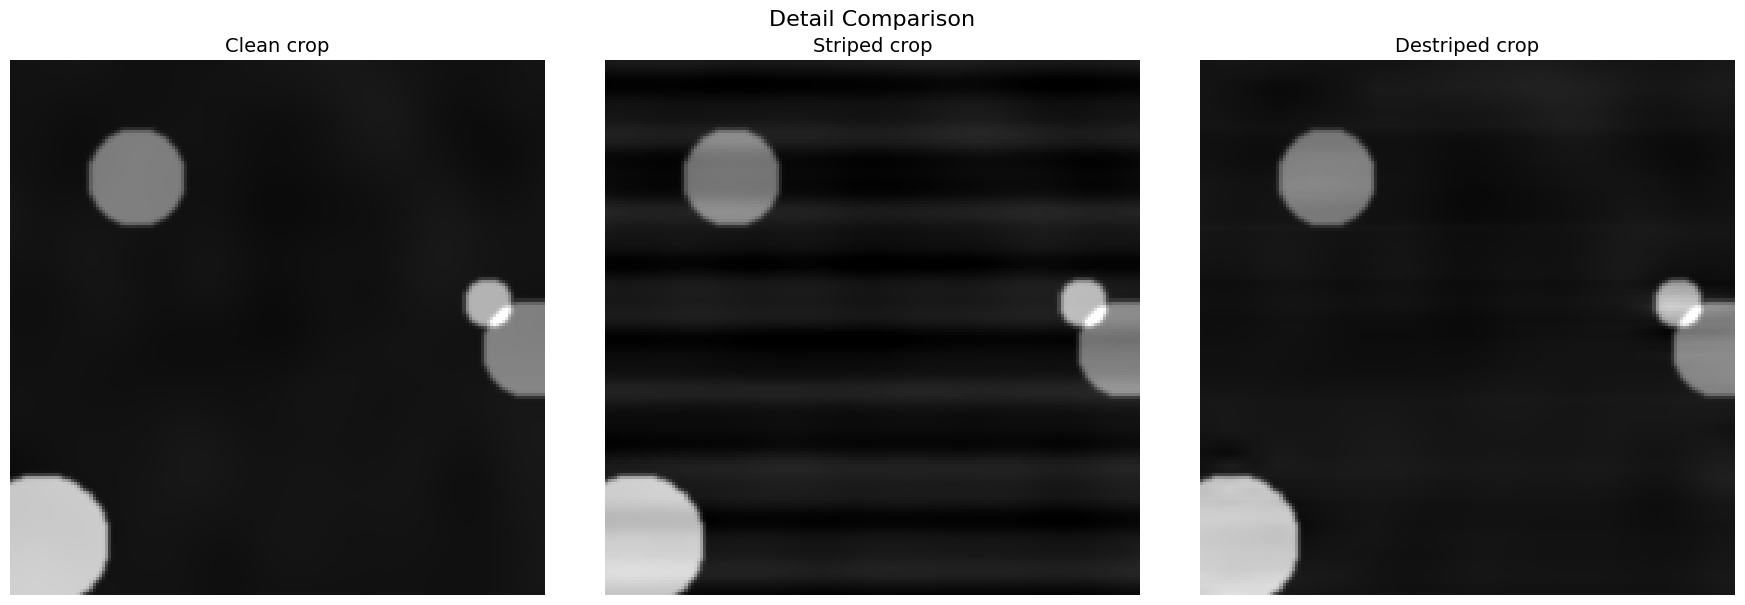

In [5]:
# Zoom in on a region to compare detail preservation.
roi = (slice(155, 330), slice(170, 345))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
crop_panels = [
    ('Clean crop', tissue),
    ('Striped crop', striped_image),
    ('Destriped crop', filtered_image),
]

for ax, (title, img) in zip(axes, crop_panels):
    ax.imshow(img[roi], cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.suptitle('Detail Comparison', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

## Parameters Guide

| Parameter | Description | Effect |
|-----------|-------------|--------|
| `sigma` | Gaussian filter bandwidth | Higher = more selective, preserves more detail |
| `max_threshold` | Wavelet coefficient threshold | Lower = more aggressive stripe removal |
| `wavelet` | Wavelet type (default: db3) | Controls decomposition basis |
| `level` | Decomposition level (None = auto) | Depth of wavelet analysis |

For light-sheet data with **faint stripes**, use a larger sigma or threshold.  
For data with **strong stripes**, lower sigma or threshold values remove more banding but can suppress real detail.